# Auto-encoding variable bayes

Adapted from https://github.com/pytorch/examples/tree/main/vae

## The Experiment

_this original bit of Science<sup>tm</sup> was done by Rachel Lowe, February 2026_

### What's being tested?
This is an ill-advised attempt at evaluating how well stochastic rounding works in the context of PyTorch.

The only stochastic rounding implementation within the context of ML-related stuff I could find for Python
was the Torchastic library (https://pypi.org/project/torchastic/), which provides a PyTorch optimizer
which allows one to train a model using stochastically-rounded `bfloat16`s.

So, this notebook attempts to evaluate the performance of 'using stochastic rounding'
(using torchastic's stochastic AdamW optimizer on a `bfloat16` model)
against 'not using stochastic rounding' (using the regular AdamW optimizer on a `bfloat16` model)
and 'not rounding' (using the regular AdamW optimizer on a `float32` model).
As a baseline, I will also be running the default configuration of the model as well (Adam optimizer, `float32`)


### How is it being tested?

This notebook contains a re-implementation of one of the pytorch example models - specifically,
the bayesian variational auto-encoder example model (https://github.com/pytorch/examples/tree/main/vae),
but with a few tweaks to record some performance metrics and produce some flashy graphs.
However, the core functionality of the model is unchanged.

What does this model do? It attempts to run a variational auto-encoder on the mnist dataset.
This attempts to interpret samples from the dataset by discovering their latent properties.
This can then be used to test the model by seeing if it can reconstruct inputs via their latent
properties (model identifies latent properties of input, produces output from model's knowledge of
those latent properties, evaluate how accurate the reconstruction was), and then can be used to
generate new outputs which (theoretically) should resemble the originals by plugging in arbitrary data.

#### Why am I testing it like this?
* Using this premade model (specifically, a model which is actively promoted as one of the PyTorch example
models: https://docs.pytorch.org/examples/) means that one can safely assume that the underlying code being used
for this experiment is somewhat sensibly-implemented and not entirely unlike the sort of code which one would
expect to see in the real world - moreso than would be possible by bodging a new model together from scratch
  * In other words - it ensures we have a baseline which won't be entirely terrible.
* I couldn't find much explicitly discussing the use of stochastic rounding in this context (VAEs) during my
cursory glance at the literature surrounding stochastic rounding - so this may or may not count as
a *totally* groundbreaking new bit of research ~~yeah right, sure it is~~
  * beats just 'finding someone else's experiment and re-running that and re-reporting their results'
* Saves me having to get used to the entire Julia ecosystem from scratch in order to run a very simple
silly little experiment with silly graphs and such ~~vs code my detested~~

~~And is this bit of totally original Science<sup>tm</sup> ultimately just going to be a waste of time and
electricity and contribute absolutely nothing of value to anyone? Yes!~~


## Hypotheses

* **Hypothesis 1** - The version of the bfloat16 model _without_ stochastic rounding will have worse performance than the bfloat16 version _with_ stochastic rounding (evaluated by test data in final epoch)
* **Hypothesis 2** The bfloat16 models will have faster training times than the float32 models.
* **Hypothesis 3** The stochastic bfloat16 model's test set loss will be in line with the float32 models
  * **3.1** stochastic bfloat16 loss will be no more than 1% higher than the highest loss of the float32 models
  * **3.2** stochastic bfloat16 loss will be closer to the average float32 loss than the non-stochastic bfloat16 loss


In [1]:
from __future__ import print_function
import argparse
import pickle

import torch
import torch.utils.data
import torchvision.utils
from torch import nn, optim, Tensor

from torch.nn import functional as F
from torch.optim import Optimizer
from torchvision import datasets, transforms
from torchvision.utils import save_image
import numpy as np

import torchastic
import matplotlib.pyplot as plt

from numbers import Number

from typing import NoReturn, Callable, Sequence, Final, Protocol, TypedDict, Literal, Union, ClassVar, List, FrozenSet, Generic, TypeVar, Set, Tuple, Callable, Iterable, Any, Dict, Iterator,Optional
import dataclasses
from dataclasses import dataclass

from time import perf_counter

import json

%matplotlib notebook


Hyper-parameters for the experiment

In [2]:

batch_size: int = 128
"""batch size for training (default: 128)"""

epochs: int = 10
"""number of epochs to train (default: 10)"""
_use_accel: bool = True
"""should accelerator be enabled"""
seed: int = 1
"""rng seed (default: 1)"""
log_interval: int = 10
"""how many batches to wait before logging training status (default: 10)"""

use_accel: bool = _use_accel and torch.accelerator.is_available()

torch.manual_seed(seed)

if use_accel:
    device = torch.accelerator.current_accelerator()
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


In [3]:
kwargs = {'num_workers': 1, 'pin_memory': True} if use_accel else {}
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=False, transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=False, **kwargs)

The model itself

In [4]:
class VAE(nn.Module):
    """
    A variational auto-encoder model.
    """
    def __init__(self, name: str, long_name: str = None):
        super(VAE, self).__init__()
        self.name: str = name
        self.long_name: str = long_name if long_name is not None else name
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)


    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    def get_name(self) -> str:
        return self.name

    def get_long_name(self) -> str:
        return self.long_name

    def get_device(self) -> torch.device:
        return next(self.parameters()).device

    def get_dtype(self) -> torch.dtype:
        return next(self.parameters()).dtype


Creating the models and the optimizers

In [5]:
model_32: VAE = VAE("adam_32", long_name="float32, Adam optimizer").to(device=device, dtype=torch.float32)
optimizer_32: optim.Optimizer = optim.Adam(model_32.parameters(), lr=1e-3)

model_w_32: VAE = VAE("adamW_32", long_name="float32, AdamW optimizer").to(device=device, dtype=torch.float32)
optimizer_w_32: optim.Optimizer = optim.AdamW(model_w_32.parameters(), lr=1e-3)

model_w_16: VAE = VAE("adamW_16", long_name="bfloat16, AdamW optimizer").to(device=device, dtype=torch.bfloat16)
optimizer_w_16: optim.Optimizer = optim.AdamW(model_w_16.parameters(), lr=1e-3)

model_sr_16: VAE = VAE("sr_adamW_16", long_name="bfloat16, Stochastic AdamW optimizer").to(device=device, dtype=torch.bfloat16)
optimizer_sr_16: optim.Optimizer = torchastic.AdamW(model_sr_16.parameters(), lr=1e-3)

The loss function

~~I'm still not entirely sure how it works~~

In [6]:
# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar,
                  dtype: torch.dtype = torch.get_default_dtype()
    ):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dtype=dtype)

    return torch.sum(BCE + KLD, dtype=dtype) #BCE + KLD


Dataclasses for storing the results of training/testing the models

In [7]:
@dataclass(init=True, frozen=True)
class EpochResult:
    """dataclass for the training results"""
    model_id: str
    epoch: int
    train_loss: Number
    train_duration: float
    test_loss: Number

    comparison_fname: str
    result_fname: str

    comparison_img: Union[None, torch.Tensor]
    result_img: Union[None, torch.Tensor]

    @classmethod
    def make(cls, id: str, epoch: int, train_loss: Number, train_duration: float, test_loss: Number, comp_fname: str, result_fname: str, comp_img: Union[None, torch.Tensor] = None, result_img: Union[None, torch.Tensor] = None) -> "EpochResult":
        return cls(id, epoch, train_loss, train_duration, test_loss, comp_fname, result_fname, comp_img, result_img)

    @classmethod
    def from_json(cls, json_str: str) -> "EpochResult":
        data = json.decoder.JSONDecoder().decode(json_str)
        return cls.make(data["model_id"], data["epoch"], data["train_loss"], data["train_duration"], data["test_loss"], data["comparison_fname"], data["result_fname"])

    def json(self) -> str:
        return json.dumps({"model_id": self.model_id, "epoch": self.epoch, "train_loss": self.train_loss, "train_duration": self.train_duration, "test_loss": self.test_loss, "comparison_fname": self.comparison_fname, "result_fname": self.result_fname}, sort_keys=True, indent=4)

    def __repr__(self) -> str:
        return f"EpochResult(model_id={self.model_id}, epoch={self.epoch}, train_loss={self.train_loss}, train_duration={self.train_duration}, test_loss={self.test_loss}, comparison_fname={self.comparison_fname}, result_fname={self.result_fname})"

dataclass(frozen=True, repr=True)
class ModelResults:
    """dataclass for the overall results of a model"""
    #epochs: tuple[EpochResult, ... ]
    "the per-epoch results of the model"

    #model_file: str

    #model_id: str
    #model_full_name: str

    def __init__(self, all_epochs: Sequence[EpochResult], model_file: str, model_name: str, model_full_name: str):
        self.epochs = tuple(all_epochs)
        self.model_file = model_file
        self.model_id = model_name
        self.model_full_name = model_full_name

    @classmethod
    def make(cls, all_epochs: Sequence[EpochResult], model: VAE, model_filename: str) -> "ModelResults":
        return cls(tuple(e for e in all_epochs), model_filename, model.get_name(), model.get_long_name())

    @property
    def epoch_count(self) -> int:
        return len(self.epochs)


    def __iter__(self) -> Iterator[EpochResult]:
        return iter(self.epochs)

    @property
    def train_durations(self) -> Iterable[float]:
        for e in self.epochs:
            yield e.train_duration
        return StopIteration

    @property
    def train_losses(self) -> Iterable[Number]:
        for e in self.epochs:
            yield e.train_loss
        return StopIteration

    @property
    def test_losses(self) -> Iterable[Number]:
        for e in self.epochs:
            yield e.test_loss
        return StopIteration

    @property
    def comparison_imgs(self) -> Iterable[torch.Tensor]:
        for e in self.epochs:
            yield e.comparison_img
        return StopIteration

    @property
    def result_imgs(self) -> Iterable[torch.Tensor]:
        for e in self.epochs:
            yield e.result_img
        return StopIteration

    @property
    def comparison_fnames(self) -> Iterable[str]:
        for e in self.epochs:
            yield e.comparison_fname
        return StopIteration

    @property
    def result_fnames(self) -> Iterable[str]:
        for e in self.epochs:
            yield e.result_fname
        return StopIteration

    def __len__(self) -> int:
        return len(self.epochs)

    def __getitem__(self, idx: int) -> EpochResult:
        for e in self.epochs:
            if e.epoch == idx:
                return e
        raise IndexError(f"Epoch {idx} does not exist. Consider querying the epochs tuple directly.")

    def json(self) -> str:
        return json.dumps({"model_file": self.model_file, "model_id": self.model_id, "model_full_name": self.model_full_name, "epochs": tuple(e.json() for e in self.epochs)}, sort_keys=True, indent=4)

    @classmethod
    def from_json(cls, json_str: str) -> "ModelResults":
        data = json.decoder.JSONDecoder().decode(json_str)
        return ModelResults(tuple(EpochResult.from_json(e) for e in data["epochs"]), data["model_file"], data["model_id"], data["model_full_name"])


Here's how I train the models

In [8]:
def train(epoch: int, model: VAE, optimizer: Optimizer) -> tuple[float, Number]:
    train_loss: Number = 0
    start_time: float = perf_counter()
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device=device, dtype=model.get_dtype())
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar, dtype=model.get_dtype())
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)))
    end_time: float = perf_counter()
    duration: float = end_time - start_time
    avg_loss: Number = train_loss / len(train_loader.dataset)
    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, avg_loss))
    return duration, avg_loss


And here's how the models get tested

In [9]:

def test(epoch, model: VAE, optimizer: Optimizer) -> tuple[Number, str, torch.Tensor, str] :
    model.eval()
    test_loss: Number = 0
    comp_fname: str = 'results/img/reconstruction_' + str(epoch) + '_' + str(model.get_name()) +  '.png'
    comp_img: torch.Tensor = torch.empty(0)
    comp_epoch: str = ""
    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            data = data.to(device).to(device=device, dtype=model.get_dtype())
            recon_batch, mu, logvar = model(data)
            test_loss += loss_function(recon_batch, data, mu, logvar).item()
            if i == 0:
                n = min(data.size(0), 8)
                #comp_img = 'results/reconstruction_' + str(epoch) + '_' + str(model.get_name()) +  '.png'
                comparison = torchvision.utils.make_grid(
                    torch.cat([data[:n],
                         recon_batch.view(batch_size, 1, 28, 28)[:n]]
                    )
                )
                #comparison = torch.cat([data[:n],
                #                      recon_batch.view(batch_size, 1, 28, 28)[:n]])
                #comp_img = 'results/reconstruction_' + str(epoch) + '_' + str(model.get_name()) +  '.png'
                save_image(comparison.cpu(),
                         comp_fname, nrow=n)
                #comp_img = comparison.cpu().permute(0,2,3,1).reshape(2 * 28, 8 * 28, 1)
                comp_epoch = str(epoch)

    test_loss /= len(test_loader.dataset)
    print('====> Test set loss: {:.4f}  {:s}'.format(test_loss, model.get_name()))
    return test_loss, comp_fname, comp_img, comp_epoch

Function for testing and training the models, along with producing the raw data and cool graphs for that model

In [10]:

def test_and_train(model: VAE, optimizer: Optimizer) -> Tuple[ModelResults, plt.Figure]:
    images: list[torch.Tensor] = []
    captions: list[str] = []

    epoch_results: list[EpochResult] = []

    fig: plt.Figure = plt.figure(figsize=(10, 4))
    plt.title(f"per-epoch results for model {str(model.get_name())}")
    plt.xlabel("epoch")
    plt.ylabel("loss")

    plt.xticks(np.arange(epochs), np.arange(1, epochs+1))

    #fig_scale : float = 2
    #plt.figure(figsize=(0.5+(2*fig_scale),0.25+(epochs * fig_scale)))
    #plt.title(f"Epoch outputs for model {str(model.get_name())}")

    for epoch in range(1, epochs + 1):
        train_duration, train_loss = train(epoch, model, optimizer)
        test_loss, comp_fname, comp_img, comp_epoch = test(epoch, model, optimizer)

        res_img: torch.Tensor
        res_fname: str = 'results/img/sample_' + str(epoch) + '_' + str(model.get_name()) + '.png'
        if comp_img is not None:
            pass
            #plt.subplot(epochs, 2 ,(2*epoch)-1)
            #plt.imshow(comp_img.to(device=device, dtype=torch.get_default_dtype()), cmap=plt.get_cmap('gray'))
            #plt.xticks([])
            #plt.yticks([])
            #plt.grid(False)
            #plt.xlabel("comparison, epoch {:s}, loss {:.4f}".format(comp_epoch, loss))


        with torch.no_grad():
            sample = torch.randn(64, 20).to(device=device, dtype=model.get_dtype())
            sample = model.decode(sample).cpu()
            #res_fname = 'results/sample_' + str(epoch) + '_' + str(model.get_name()) + '.png'

            #save_image(sample.view(64, 1, 28, 28),
            #           'results/sample_' + str(epoch) + '_' + str(model.get_name()) + '.png')
            #images.append(sample.view(64,1,28,28))
            res_img = torchvision.utils.make_grid(sample.view(64,1,28,28), nrow=8)
            save_image(res_img, res_fname)
            captions.append(f"epoch {str(epoch)}")

            #plt.subplot(epochs,2,2*epoch)
            #plt.imshow(sample.view(64, 1, 28, 28).permute(0,2,3,1).reshape(28 * 8, 28 * 8, 1).to(device=device, dtype=torch.get_default_dtype()), cmap=plt.get_cmap('gray'))
            #plt.xticks([])
            #plt.yticks([])
            #plt.grid(False)
            #plt.xlabel("epoch {:f}, test set loss {:.4f}".format(epoch, loss))
        epoch_results.append(EpochResult.make(model.get_name(), epoch, train_loss, train_duration, test_loss, comp_fname=comp_fname, result_fname=res_fname, comp_img=comp_img, result_img=res_img))

    model_fname: str = 'models/' + str(model.get_name()) + '.pt'
    torch.save(model.state_dict(), model_fname)

    results = ModelResults.make(epoch_results, model, model_fname)

    plt.plot(tuple(results.train_losses), label="train loss")
    plt.plot(tuple(results.test_losses), label="test loss")

    plt.legend()


    #fig.show()

    return results, fig
    #plt.show()



And now, testing/training the models and storing the results

<IPython.core.display.Javascript object>

Train Epoch: 1 [0/60000 (0%)]	Loss: 550.829163
Train Epoch: 1 [1280/60000 (2%)]	Loss: 301.206390
Train Epoch: 1 [2560/60000 (4%)]	Loss: 237.769760
Train Epoch: 1 [3840/60000 (6%)]	Loss: 220.451355
Train Epoch: 1 [5120/60000 (9%)]	Loss: 215.235016
Train Epoch: 1 [6400/60000 (11%)]	Loss: 206.794235
Train Epoch: 1 [7680/60000 (13%)]	Loss: 200.540512
Train Epoch: 1 [8960/60000 (15%)]	Loss: 203.359329
Train Epoch: 1 [10240/60000 (17%)]	Loss: 190.184540
Train Epoch: 1 [11520/60000 (19%)]	Loss: 188.948059
Train Epoch: 1 [12800/60000 (21%)]	Loss: 186.859848
Train Epoch: 1 [14080/60000 (23%)]	Loss: 168.070053
Train Epoch: 1 [15360/60000 (26%)]	Loss: 169.581985
Train Epoch: 1 [16640/60000 (28%)]	Loss: 168.392563
Train Epoch: 1 [17920/60000 (30%)]	Loss: 168.656860
Train Epoch: 1 [19200/60000 (32%)]	Loss: 157.982391
Train Epoch: 1 [20480/60000 (34%)]	Loss: 155.281952
Train Epoch: 1 [21760/60000 (36%)]	Loss: 156.715866
Train Epoch: 1 [23040/60000 (38%)]	Loss: 149.845627
Train Epoch: 1 [24320/60000 

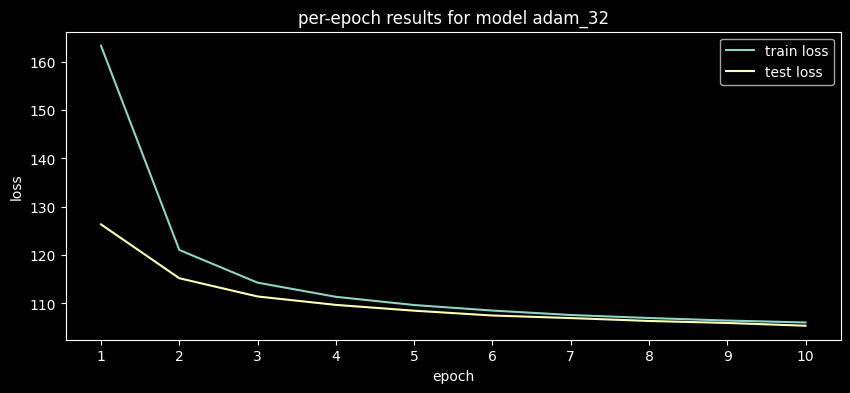

In [11]:
results_adam_32, fig_adam_32 = test_and_train(model_32, optimizer_32)

#fig_adam_32.show()
fig_adam_32

In [12]:
json.dump(results_adam_32.json(), open("results/adam_32.json", "w"))

In [13]:
pickle.dump(results_adam_32, open("results/adam_32.pkl", "wb"))

<IPython.core.display.Javascript object>

Train Epoch: 1 [0/60000 (0%)]	Loss: 546.702454
Train Epoch: 1 [1280/60000 (2%)]	Loss: 302.440857
Train Epoch: 1 [2560/60000 (4%)]	Loss: 233.375031
Train Epoch: 1 [3840/60000 (6%)]	Loss: 226.295563
Train Epoch: 1 [5120/60000 (9%)]	Loss: 212.299683
Train Epoch: 1 [6400/60000 (11%)]	Loss: 214.636230
Train Epoch: 1 [7680/60000 (13%)]	Loss: 209.731003
Train Epoch: 1 [8960/60000 (15%)]	Loss: 201.997787
Train Epoch: 1 [10240/60000 (17%)]	Loss: 194.090134
Train Epoch: 1 [11520/60000 (19%)]	Loss: 194.483643
Train Epoch: 1 [12800/60000 (21%)]	Loss: 181.725891
Train Epoch: 1 [14080/60000 (23%)]	Loss: 179.297028
Train Epoch: 1 [15360/60000 (26%)]	Loss: 176.675446
Train Epoch: 1 [16640/60000 (28%)]	Loss: 167.155579
Train Epoch: 1 [17920/60000 (30%)]	Loss: 171.774536
Train Epoch: 1 [19200/60000 (32%)]	Loss: 162.434998
Train Epoch: 1 [20480/60000 (34%)]	Loss: 161.670227
Train Epoch: 1 [21760/60000 (36%)]	Loss: 160.458893
Train Epoch: 1 [23040/60000 (38%)]	Loss: 163.288147
Train Epoch: 1 [24320/60000 

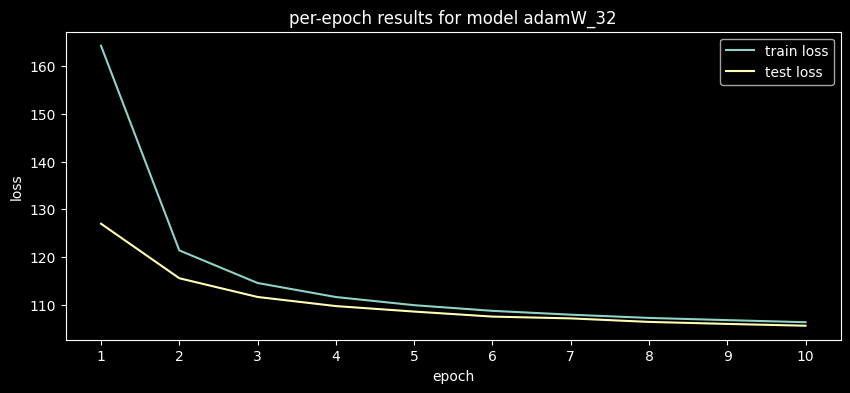

In [14]:
results_adamw_32, fig_adamw_32 = test_and_train(model_w_32, optimizer_w_32)

fig_adamw_32#.show()

In [15]:
json.dump(results_adamw_32.json(), open("results/adamw_32.json", "w"))

In [16]:
pickle.dump(results_adamw_32, open("results/adamw_32.pkl", "wb"))

<IPython.core.display.Javascript object>

Train Epoch: 1 [0/60000 (0%)]	Loss: 548.000000
Train Epoch: 1 [1280/60000 (2%)]	Loss: 292.000000
Train Epoch: 1 [2560/60000 (4%)]	Loss: 236.000000
Train Epoch: 1 [3840/60000 (6%)]	Loss: 217.000000
Train Epoch: 1 [5120/60000 (9%)]	Loss: 214.000000
Train Epoch: 1 [6400/60000 (11%)]	Loss: 208.000000
Train Epoch: 1 [7680/60000 (13%)]	Loss: 196.000000
Train Epoch: 1 [8960/60000 (15%)]	Loss: 195.000000
Train Epoch: 1 [10240/60000 (17%)]	Loss: 190.000000
Train Epoch: 1 [11520/60000 (19%)]	Loss: 183.000000
Train Epoch: 1 [12800/60000 (21%)]	Loss: 179.000000
Train Epoch: 1 [14080/60000 (23%)]	Loss: 179.000000
Train Epoch: 1 [15360/60000 (26%)]	Loss: 174.000000
Train Epoch: 1 [16640/60000 (28%)]	Loss: 171.000000
Train Epoch: 1 [17920/60000 (30%)]	Loss: 172.000000
Train Epoch: 1 [19200/60000 (32%)]	Loss: 156.000000
Train Epoch: 1 [20480/60000 (34%)]	Loss: 159.000000
Train Epoch: 1 [21760/60000 (36%)]	Loss: 161.000000
Train Epoch: 1 [23040/60000 (38%)]	Loss: 159.000000
Train Epoch: 1 [24320/60000 

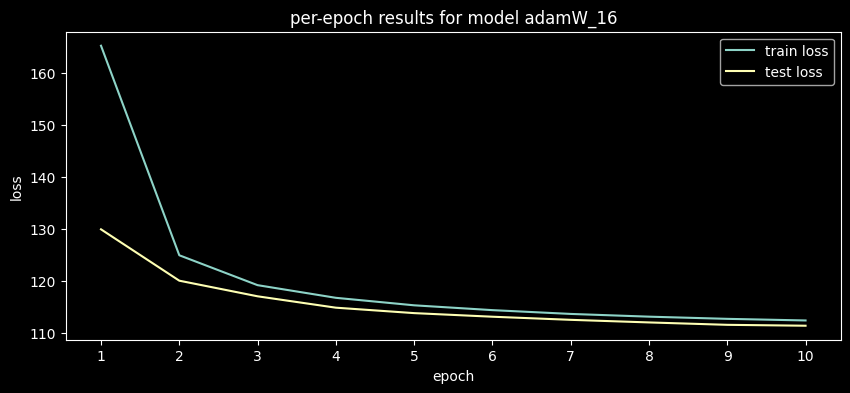

In [17]:
results_adamw_16, fig_adamw_16 = test_and_train(model_w_16, optimizer_w_16)

fig_adamw_16#.show()

In [18]:
json.dump(results_adamw_16.json(), open("results/adamw_16.json", "w"))

In [19]:
pickle.dump(results_adamw_16, open("results/adamw_16.pkl", "wb"))

<IPython.core.display.Javascript object>

Train Epoch: 1 [0/60000 (0%)]	Loss: 552.000000
Train Epoch: 1 [1280/60000 (2%)]	Loss: 300.000000
Train Epoch: 1 [2560/60000 (4%)]	Loss: 248.000000
Train Epoch: 1 [3840/60000 (6%)]	Loss: 220.000000
Train Epoch: 1 [5120/60000 (9%)]	Loss: 213.000000
Train Epoch: 1 [6400/60000 (11%)]	Loss: 209.000000
Train Epoch: 1 [7680/60000 (13%)]	Loss: 209.000000
Train Epoch: 1 [8960/60000 (15%)]	Loss: 208.000000
Train Epoch: 1 [10240/60000 (17%)]	Loss: 197.000000
Train Epoch: 1 [11520/60000 (19%)]	Loss: 188.000000
Train Epoch: 1 [12800/60000 (21%)]	Loss: 185.000000
Train Epoch: 1 [14080/60000 (23%)]	Loss: 178.000000
Train Epoch: 1 [15360/60000 (26%)]	Loss: 178.000000
Train Epoch: 1 [16640/60000 (28%)]	Loss: 171.000000
Train Epoch: 1 [17920/60000 (30%)]	Loss: 162.000000
Train Epoch: 1 [19200/60000 (32%)]	Loss: 163.000000
Train Epoch: 1 [20480/60000 (34%)]	Loss: 163.000000
Train Epoch: 1 [21760/60000 (36%)]	Loss: 160.000000
Train Epoch: 1 [23040/60000 (38%)]	Loss: 155.000000
Train Epoch: 1 [24320/60000 

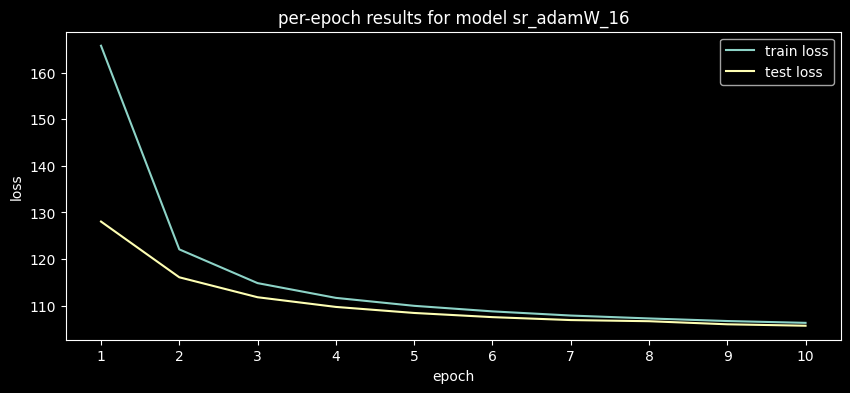

In [20]:
results_sr_16, fig_sr_16 = test_and_train(model_sr_16, optimizer_sr_16)

fig_sr_16#.show()

In [21]:
json.dump(results_sr_16.json(), open("results/sr_adamw_16.json", "w"))

In [22]:
pickle.dump(results_sr_16, open("results/adamw_16.pkl", "wb"))

# Comparing the trained models to each other

Due to some current (as of 24/2/2026) issues with running PyTorch using ROCm on Linux,
these tests have been run on one of two ancient CPUs instead - which, looking at the execution times,
probably ended up backfiring (due to a lack of support for bfloat16 on CPUs).

In [35]:
results_dict: dict[str, ModelResults] = {
    "baseline (float32 adam)": results_adam_32,
    "float32 adamw": results_adamw_32,
    "bfloat16 adamw": results_adamw_16,
    "stochastic bfloat16 adamw": results_sr_16,
}

In [37]:
def grid_stuff(ax: plt.Axes, both: bool = False) -> None:
    ax.grid(which='major', color='#666666', linestyle='-', axis = "both" if both else "y")
    ax.grid(which='minor', color='#999999', linestyle='-', axis = "both" if both else "y", alpha=0.2)
    return


<IPython.core.display.Javascript object>

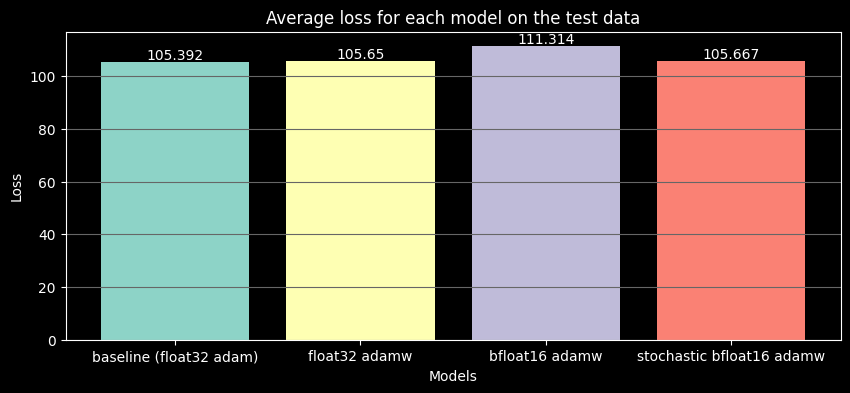

In [39]:

fig_loss: plt.Figure = plt.figure(figsize=(10, 4))

final_losses: list[Number] = [res[epochs].test_loss for res in results_dict.values()]

bars1 = plt.bar(results_dict.keys(), final_losses, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.bar_label(bars1)
#ax1.legend()
plt.title("Average loss for each model on the test data")
ax_loss: plt.Axes = fig_loss.get_axes()[0]
grid_stuff(ax_loss)
ax_loss.set_ylabel("Loss")
ax_loss.set_xlabel("Models")

fig_loss

<IPython.core.display.Javascript object>

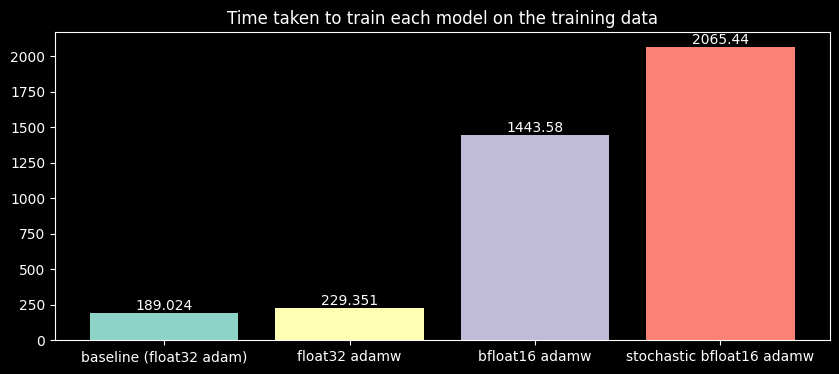

In [40]:


## Bar chart of time taken for training each model
fig_time: plt.Figure = plt.figure(figsize=(10, 4))

training_times: list[float] = [sum(epoch.train_duration for epoch in info) for info in results_dict.values()]
bars2 = plt.bar(results_dict.keys(), training_times, color=plt.rcParams['axes.prop_cycle'].by_key()['color'])
plt.bar_label(bars2)
#ax2.legend()
plt.title("Time taken to train each model on the training data")
ax_time: plt.Axes = fig_loss.get_axes()[0]
grid_stuff(ax_time)
ax_time.set_ylabel("Training duration (seconds)")
ax_time.set_xlabel("Models")

fig_time

Did the stochastic float16 model provide a better result than the non-stochastic bfloat16 model?

In [63]:
sr_bfloat16_loss = results_sr_16[epochs].test_loss
bfloat16_loss = results_adamw_16[epochs].test_loss

if sr_bfloat16_loss < bfloat16_loss:
    print("The stochastic bfloat16 model was more accurate than the non-stochastic bfloat16 model!")
    print("Hypothesis 1 supported!")
else:
    print("The non-stochastic bfloat16 model was more accurate than the stochastic version!")
    print("Hypothesis 1 debunked!")

print("")
print(f"stochastic loss: {sr_bfloat16_loss}")
print(f"non-stochastic:  {bfloat16_loss}")

The stochastic bfloat16 model was more accurate than the non-stochastic bfloat16 model!
Hypothesis 1 supported!

stochastic loss: 105.6666203125
non-stochastic:  111.3143091796875


Did the stochastic bfloat16 model have the shortest training time?

In [64]:
model_time_res: list[ModelResults] = [results_adam_32, results_adamw_32, results_adamw_16, results_sr_16]
model_time_res.sort(key=lambda res: sum(epoch.train_duration for epoch in res))

print("== training durations ==")
print(f"{'model id':12}training duration (seconds)")
for m in model_time_res:
    print(f"{m.model_id:12}{sum(epoch.train_duration for epoch in m)}")

print("")
if model_time_res[0].model_id == results_sr_16.model_id:
    print("The stochastic rounding had the fastest training time!")
    print("\tHypothesis 2 supported!")
else:
    print("The stochastic rounding model didn't have the fastest training time!")
    print("\tHypothesis 2 debunked!")


== training durations ==
model id    training duration (seconds)
adam_32     189.0238293999996
adamW_32    229.35095760000058
adamW_16    1443.5808184000002
sr_adamW_16 2065.4364036999996

The stochastic rounding model didn't have the fastest training time!
	Hypothesis 2 debunked!


Was the overall loss of the stochastic bfloat16 model no more than 1% higher than the worst float32 model?

In [65]:
worst_float32_loss = max(results_adam_32[epochs].test_loss, results_adam_32[epochs].test_loss)
sr_bfloat16_loss = results_sr_16[epochs].test_loss
bfloat16_loss = results_adamw_16[epochs].test_loss


if sr_bfloat16_loss <= (worst_float32_loss * 1.01):
    print("The stochastic loss is no more than 1% higher than the worst float32 model!")
    print("\tHypothesis 3.1 supported!")
else:
    print("The stochastic model's loss is over 1% higher than the worse float32 model!")
    print("\tHypothesis 3.1 debunked!")

print("")

print(f"it is only {(sr_bfloat16_loss-worst_float32_loss)/worst_float32_loss}% worse")
print(f"stochastic: {sr_bfloat16_loss}")
print(f"worst f32:  {worst_float32_loss}")
print(f"difference: {(sr_bfloat16_loss-worst_float32_loss)} more loss in bfloat16 (lower = bfloat16 did better)")

print("")

midpoint_between_losses = (worst_float32_loss + bfloat16_loss)/2
if sr_bfloat16_loss < midpoint_between_losses:
    print("stochastic loss is closer to the float32 losses than the non-stochastic bfloat16 loss")
    print("\tHypothesis 3.2 supported!")
else:
    print("stochastic loss is closer to non-stochastic bfloat16 loss to the float32 losses")
    print("\tHypothesis 3.2 debunked!")

print("")
print("== all test data loss results ==")
print(f"{'model id':12}final test loss")
for m in [results_adam_32, results_adamw_32, results_adamw_16, results_sr_16]:
    print(f"{m.model_id:12}{m[epochs].test_loss}")


The stochastic loss is no more than 1% higher than the worst float32 model!
	Hypothesis 3.1 supported!

it is only 0.002602519632170243% worse
stochastic: 105.6666203125
worst f32:  105.39233469238282
difference: 0.27428562011718327 more loss in bfloat16 (lower = bfloat16 did better)

stochastic loss is closer to the float32 losses than the non-stochastic bfloat16 loss
	Hypothesis 3.2 supported!

== all test data loss results ==
model id    final test loss
adam_32     105.39233469238282
adamW_32    105.65049005126953
adamW_16    111.3143091796875
sr_adamW_16 105.6666203125
